In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Import dataset with a specified encoding
df = pd.read_csv(r"C:\Users\artan\Downloads\superstore_final_dataset.csv", encoding='latin1')
df.head()


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [4]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

In [5]:
#Preparing the Data
X = df.drop(['Sales', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Segment', 'City', 'State', 'Region', 'Category', 'Sub_Category'], axis=1)
y = df['Region']

In [6]:
X.shape

(9800, 8)

In [7]:
y.shape

(9800,)

In [8]:
#Training and Making Predictions
from sklearn.model_selection import train_test_split # Import train_test_split function
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [9]:
X_train.shape

(7840, 8)

In [10]:
X_test.shape

(1960, 8)

In [11]:
y_train.shape

(7840,)

In [12]:
y_test.shape

(1960,)

In [13]:
X_train

,Row_ID,Order_ID,Customer_ID,Customer_Name,Country,Postal_Code,Product_ID,Product_Name
46,47,CA-2015-146703,PO-18865,Patrick O Donnel,United States,48185.0,OFF-ST-10001713,"Gould Plastics 9-Pocket Panel Bin, 18-3/8w x 5..."
2039,2040,CA-2016-122287,SN-20560,Skye Norling,United States,85345.0,OFF-BI-10004656,Peel & Stick Add-On Corner Pockets
3008,3009,CA-2017-124772,JG-15160,James Galang,United States,42071.0,FUR-FU-10004748,Howard Miller 16 Diameter Gallery Wall Clock
9085,9086,CA-2017-126102,DV-13465,Dianna Vittorini,United States,90049.0,OFF-BI-10004318,Ibico EB-19 Dual Function Manual Binding System
4206,4207,CA-2015-145387,AM-10705,Anne McFarland,United States,2920.0,OFF-BI-10004001,GBC Recycled VeloBinder Covers
...,...,...,...,...,...,...,...,...
1007,1008,CA-2016-105312,MT-17815,Meg Tillman,United States,85254.0,OFF-BI-10002049,UniKeep View Case Binders
4380,4381,CA-2016-152891,TB-21625,Trudy Brown,United States,94110.0,OFF-AR-10004648,Boston 19500 Mighty Mite Electric Pencil Sharp...
2830,2831,CA-2017-124149,MJ-17740,Max Jones,United States,43130.0,OFF-PA-10002923,Xerox 1942
588,589,US-2017-156986,ZC-21910,Zuschuss Carroll,United States,97301.0,TEC-PH-10003800,i.Sound Portable Power - 8000 mAh


In [14]:
y_train

46      Central
2039       West
3008      South
9085       West
4206       East
         ...   
1007       West
4380       West
2830       East
588        West
6962      South
Name: Region, Length: 7840, dtype: object

In [15]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply Label Encoding to categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Decision Tree classifier object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifier
clf = clf.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = clf.predict(X_test)

# Print the predictions
print(y_pred)


['West' 'East' 'Central' ... 'Central' 'East' 'South']


In [16]:
predictions = clf.predict(X_test)
predictions

array(['West', 'East', 'Central', ..., 'Central', 'East', 'South'],
      dtype=object)

In [17]:
# show difference between tree that doesn't have stopping criteria and the one that does
clf.predict_proba(X_test)

array([[0.        , 0.        , 0.        , 1.        ],
       [0.        , 1.        , 0.        , 0.        ],
       [0.98905473, 0.        , 0.        , 0.01094527],
       ...,
       [0.9140625 , 0.        , 0.0859375 , 0.        ],
       [0.        , 1.        , 0.        , 0.        ],
       [0.        , 0.00167645, 0.99832355, 0.        ]])

In [18]:
#Evaluating the Algorithm
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[464   0   0   0]
 [  0 518   2   0]
 [ 24   0 306   0]
 [  4   0   0 642]]
              precision    recall  f1-score   support

     Central       0.94      1.00      0.97       464
        East       1.00      1.00      1.00       520
       South       0.99      0.93      0.96       330
        West       1.00      0.99      1.00       646

    accuracy                           0.98      1960
   macro avg       0.98      0.98      0.98      1960
weighted avg       0.99      0.98      0.98      1960



In [19]:
# Model Accuracy, how often is the classifier correct?
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9846938775510204


In [20]:
feature_names = X.columns
feature_names

Index(['Row_ID', 'Order_ID', 'Customer_ID', 'Customer_Name', 'Country',
       'Postal_Code', 'Product_ID', 'Product_Name'],
      dtype='object')

In [21]:
clf.feature_importances_

array([0., 0., 0., 0., 0., 1., 0., 0.])

In [22]:
feature_importance = pd.DataFrame(clf.feature_importances_, index = feature_names).sort_values(0, ascending=False)
feature_importance

,0
Postal_Code,1.0
Row_ID,0.0
Order_ID,0.0
Customer_ID,0.0
Customer_Name,0.0
Country,0.0
Product_ID,0.0
Product_Name,0.0


In [23]:
features = list(feature_importance[feature_importance[0]>0].index)
features

['Postal_Code']

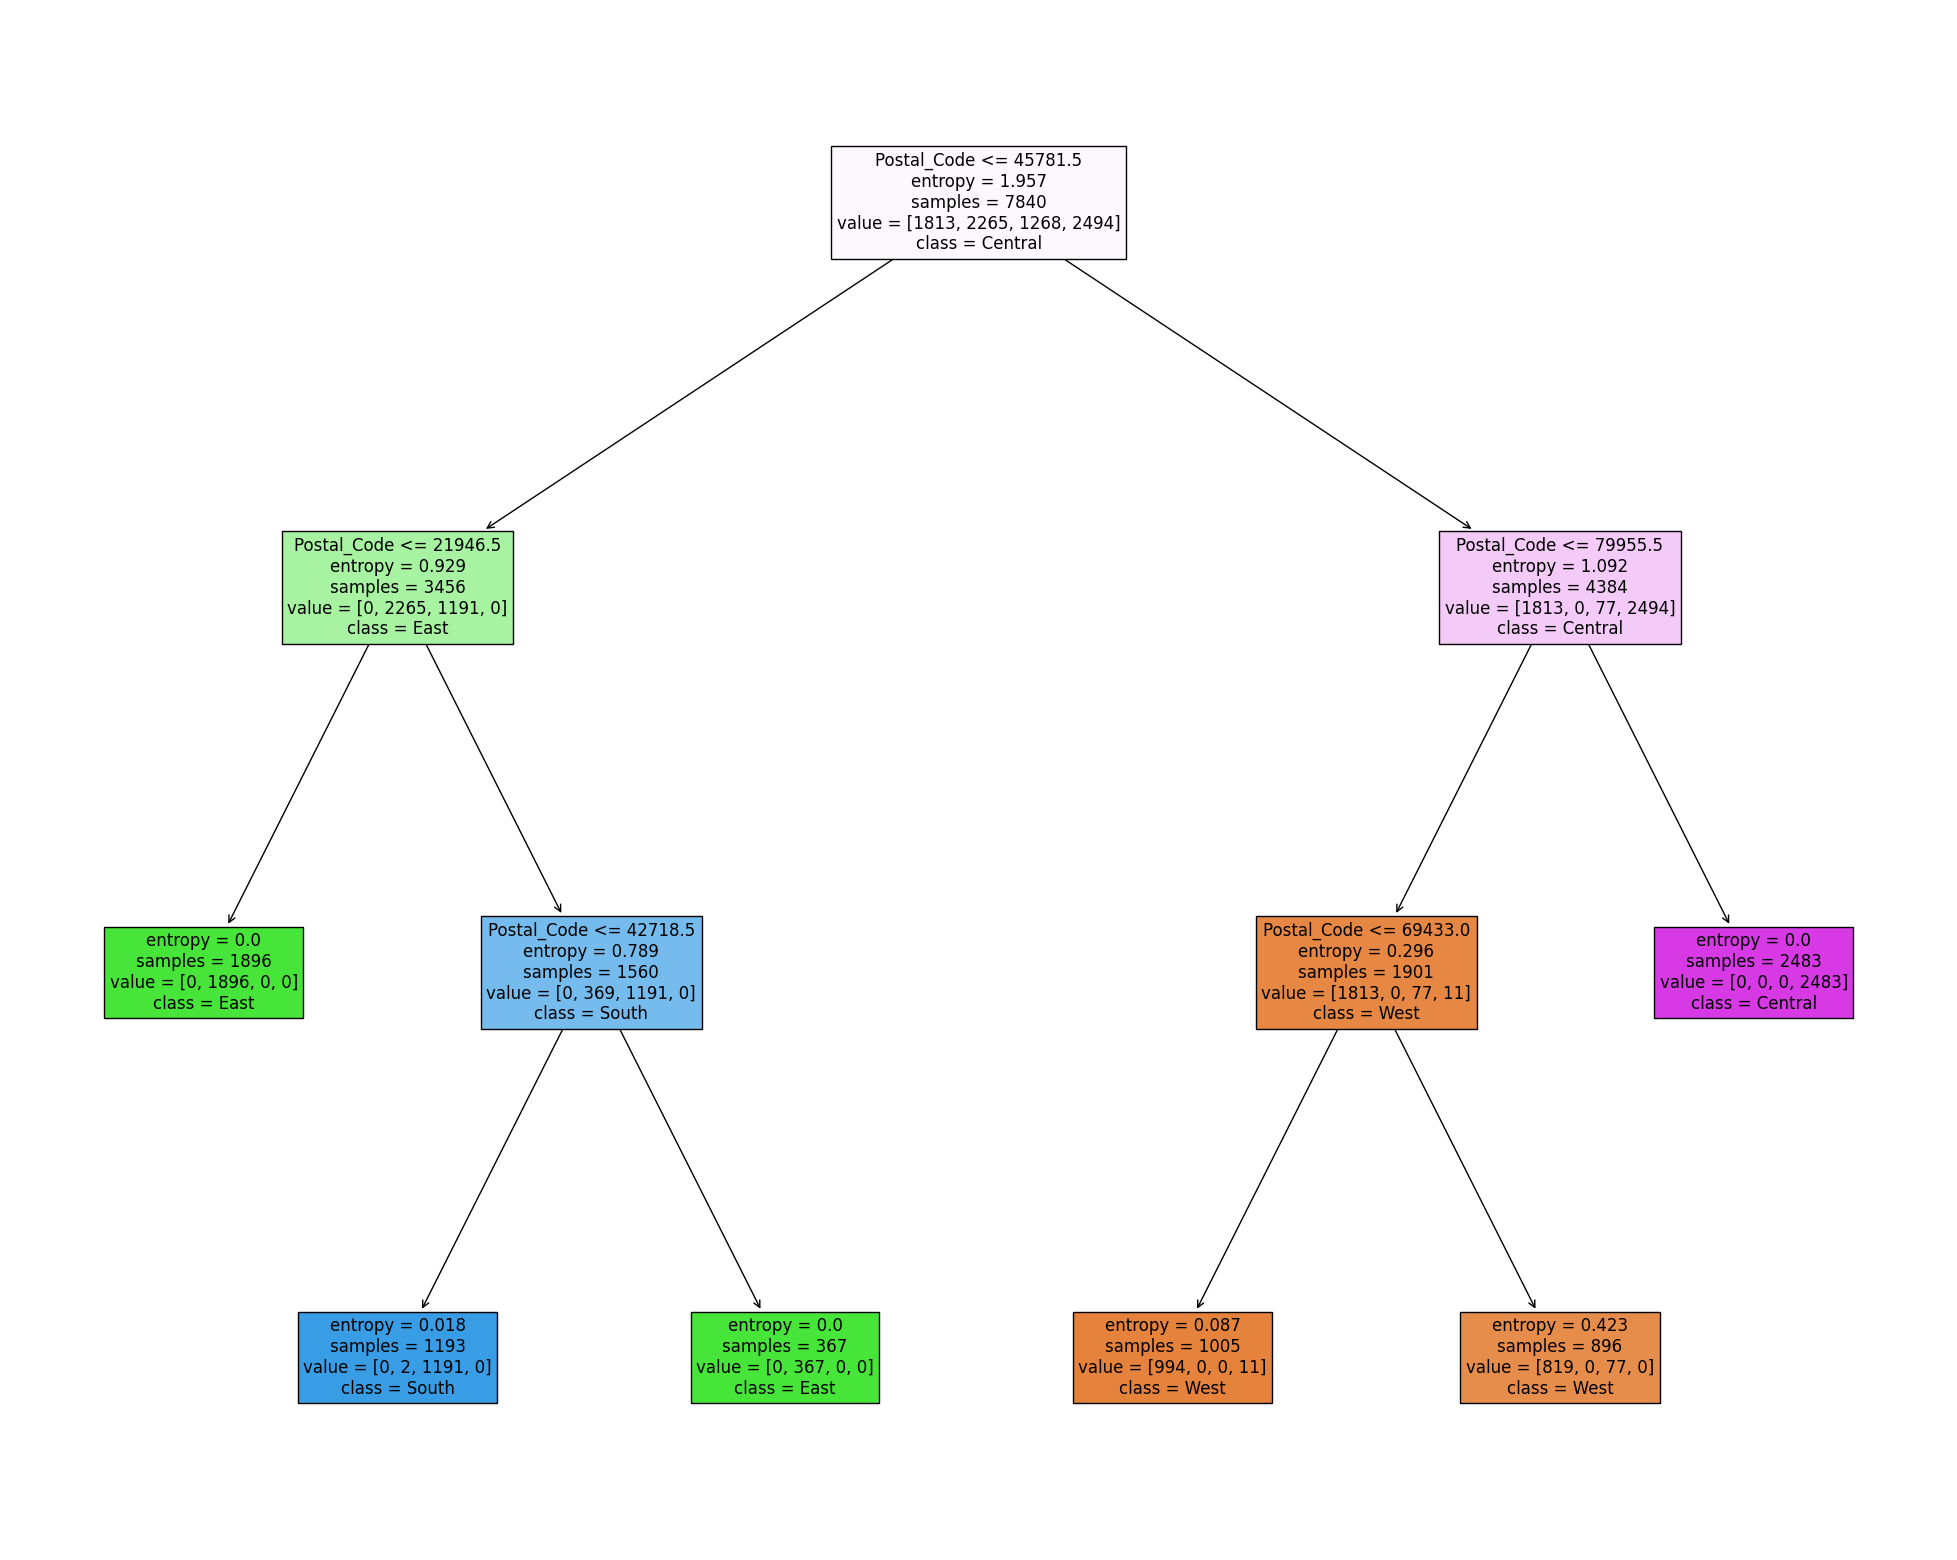

In [24]:
from sklearn import tree
from matplotlib import pyplot as plt

# Convert the Index object to a list
feature_names_list = list(feature_names)

# Convert the class_names dictionary to a list
class_names_list = ['West', 'East', 'South', 'Central']

fig = plt.figure(figsize=(25, 20))
_ = tree.plot_tree(clf, 
                feature_names=feature_names_list,
                class_names=class_names_list,
                filled=True,
                fontsize=12)
plt.show()
